In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=100,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        n_estimators=100,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:35:30] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7941176470588235
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.71      0.38      0.50        13
           4       0.57      0.70      0.63        46
           5       0.91      0.98      0.94       875
           6       0.89      0.94      0.92       106
           7       0.64      0.33      0.44        21
           8       0.78      0.77      0.77        98
           9       0.00      0.00      0.00         5
          10       0.70      0.88      0.78       208
          11       0.56      0.75      0.64        12
          12       0.52      0.59      0.55        88
          13       0.00      0.00      0.00        12
          14       0.14      0.02      0.03        52
          15       0.80      0.80      0.80         5


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('svm', SVC(C=100,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        n_estimators=100,
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=100,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        max_depth=5,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.078562 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [18:14:17] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7956656346749226
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.67      0.46      0.55        13
           4       0.56      0.65      0.60        46
           5       0.92      0.98      0.95       875
           6       0.89      0.94      0.92       106
           7       0.78      0.33      0.47        21
           8       0.78      0.76      0.77        98
           9       0.00      0.00      0.00         5
          10       0.71      0.89      0.79       208
          11       0.56      0.75      0.64        12
          12       0.50      0.58      0.54        88
          13       0.00      0.00      0.00        12
          14       0.30      0.06      0.10        52
          15       0.80      0.80      0.80         5


In [3]:
import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    Weighted log‐loss L = - sum_i w_{y_i} * log(p_hat_i),
    where w_y = 1 / f_y (no further normalization).
    Returns the *average* per sample (i.e. L / N).
    
    y_true:       array-like of shape (N,), integer class labels 0…C-1
    y_pred_proba: array of shape (N, C), predicted class probabilities
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape
    
    # 1) compute class frequencies f_y
    class_counts = np.bincount(y_true, minlength=C)
    #    avoid division by zero if some class is missing
    class_counts[class_counts == 0] = 1
    
    # 2) define w_y = 1 / f_y
    class_weights = 1.0 / class_counts
    
    # 3) extract p_hat_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)
    
    # 4) weighted log loss
    losses = - class_weights[y_true] * np.log(p)
    
    # 5) return average per sample
    return np.sum(losses) / N
    
y_val_proba = ensemble.predict_proba(X_val)
wll_formula = weighted_log_loss_formula(y_val, y_val_proba)
print("Weighted log‐loss (by formula):", wll_formula)


Weighted log‐loss (by formula): 0.037042216761802665


In [5]:
import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")


Training weighted log‐loss:   0.0001
Validation weighted log‐loss: 0.0370


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, log_loss
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import StackingClassifier

from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ----------------------------
# 1. Weighted log-loss formula
# ----------------------------
def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape
    class_counts = np.bincount(y_true, minlength=C)
    class_counts[class_counts == 0] = 1
    class_weights = 1.0 / class_counts
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)
    losses = - class_weights[y_true] * np.log(p)
    return losses.sum() / N

# -----------------------------------
# 2. Cost-sensitive XGBoost wrapper
# -----------------------------------
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        w = compute_sample_weight('balanced', y)
        return super().fit(X, y, sample_weight=w, **kwargs)

# ----------------------------
# 3. Load & split the dataset
# ----------------------------
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# 4. Define base pipelines
# ----------------------------
pipe_lr = ImbPipeline([
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(
        C=0.215, solver='lbfgs',
        class_weight='balanced', max_iter=2000, random_state=42
    ))
])

pipe_svm = ImbPipeline([
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(
        C=100, class_weight='balanced',
        probability=True, random_state=42
    ))
])

pipe_lgbm = ImbPipeline([
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(
        learning_rate=0.05, n_estimators=200,
        class_weight='balanced', random_state=42
    ))
])

pipe_xgb = ImbPipeline([
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1, n_estimators=100,
        objective='multi:softprob', num_class=len(np.unique(y_train)),
        eval_metric='mlogloss', random_state=42
    ))
])

# ----------------------------
# 5. Build & train stacking
# ----------------------------
stack = StackingClassifier(
    estimators=[
        ('lr',  pipe_lr),
        ('svm', pipe_svm),
        ('lgbm',pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    final_estimator=LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs',
        class_weight='balanced', max_iter=2000, random_state=42
    ),
    cv=5,
    n_jobs=4,
    passthrough=False
)
stack.fit(X_train, y_train)

# ----------------------------
# 6. Evaluate stacking
# ----------------------------
# Predictions
y_pred_train = stack.predict(X_train)
y_pred_val   = stack.predict(X_val)

# Probabilities for weighted log-loss
y_proba_train = stack.predict_proba(X_train)
y_proba_val   = stack.predict_proba(X_val)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_val   = accuracy_score(y_val,   y_pred_val)

# Classification report on validation
clf_report = classification_report(y_val, y_pred_val, zero_division=0)

# Weighted log-loss
train_wll = weighted_log_loss_formula(y_train, y_proba_train)
val_wll   = weighted_log_loss_formula(y_val,   y_proba_val)

print(f"Stacking Training Accuracy:   {acc_train:.4f}")
print(f"Stacking Validation Accuracy: {acc_val:.4f}\n")
print("Stacking Validation Classification Report:\n", clf_report)
print(f"Stacking Training Weighted Log-Loss:   {train_wll:.4f}")
print(f"Stacking Validation Weighted Log-Loss: {val_wll:.4f}")

# ----------------------------
# 7. Plot Train vs Validation Weighted Log-Loss
# ----------------------------
plt.figure(figsize=(6,4))
plt.plot(['Train','Validation'], [train_wll, val_wll], marker='o')
plt.ylabel('Weighted Log-Loss')
plt.title('Stacking: Train vs Validation Weighted Log-Loss')
plt.grid(True)
plt.show()


Baseline LR Training Accuracy:   0.8622
Baseline LR Validation Accuracy: 0.6791

Baseline LR Validation Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.38      0.46      0.41        13
           4       0.40      0.59      0.48        46
           5       0.96      0.76      0.85       875
           6       0.86      0.89      0.87       106
           7       0.52      0.52      0.52        21
           8       0.76      0.64      0.70        98
           9       0.20      0.20      0.20         5
          10       0.77      0.68      0.72       208
          11       0.64      0.75      0.69        12
          12       0.55      0.53      0.54        88
          13       0.00      0.00      0.00        12
          14       0.13      0.50      0.20        52
       

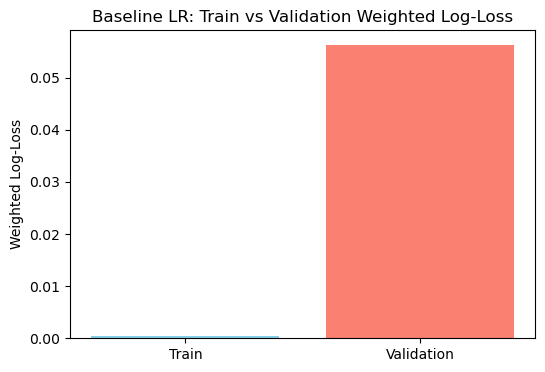

Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.070558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [23:50:30] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7894736842105263
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.56      0.38      0.45        13
           4       0.55      0.61      0.58        46
           5       0.91      0.96      0.94       875
           6       0.92      0.94      0.93       106
           7       0.78      0.33      0.47        21
           8       0.79      0.79      0.79        98
           9       0.00      0.00      0.00         5
          10       0.71      0.90      0.79       208
          11       0.53      0.67      0.59        12
          12       0.49      0.58      0.53        88
          13       0.00      0.00      0.00        12
          14       0.17      0.08      0.11        52
          15       0.80      0.80      0.80         5


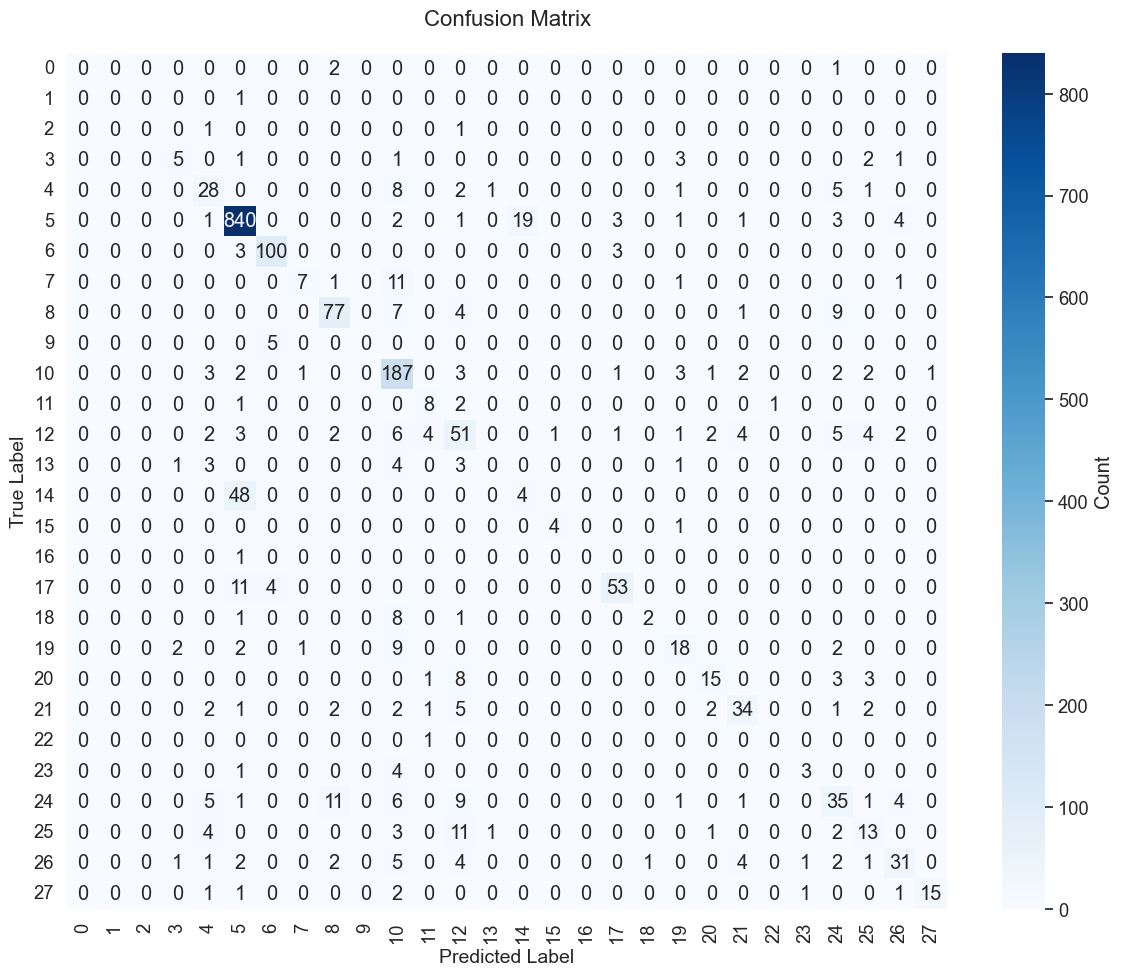

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=0.1,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
#    Replace y_true and y_pred with your variables
y_true = y_val
y_pred = y_pred
cm = confusion_matrix(y_true, y_pred)

# 2. (Optional) If you want the labels in sorted order, e.g. [0,1,2,...]
classes = np.unique(y_true)

# 3. Plot
plt.figure(figsize=(12,10))
sns.set(font_scale=1.2)  # for label size
ax = sns.heatmap(
    cm,
    annot=True,            # write the data in each cell
    fmt='d',               # integer format
    cmap='Blues',          # or any other colormap
    cbar_kws={'label': 'Count'},
    xticklabels=classes,
    yticklabels=classes
)

# 4. Decorations
ax.set_title('Confusion Matrix', fontsize=16, pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0)     # keep y‐tick labels horizontal
plt.xticks(rotation=90)    # rotate x‐tick labels if they’re long
plt.tight_layout()
plt.show()


Training weighted log‐loss:   0.0004
Validation weighted log‐loss: 0.0372


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105678 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [15:34:55] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7956656346749226
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.67      0.46      0.55        13
           4       0.56      0.65      0.60        46
           5       0.92      0.98      0.95       875
           6       0.89      0.94      0.92       106
           7       0.78      0.33      0.47        21
           8       0.78      0.76      0.77        98
           9       0.00      0.00      0.00         5
          10       0.71      0.89      0.79       208
          11       0.56      0.75      0.64        12
          12       0.50      0.58      0.54        88
          13       0.00      0.00      0.00        12
          14       0.30      0.06      0.10        52
          15       0.80      0.80      0.80         5


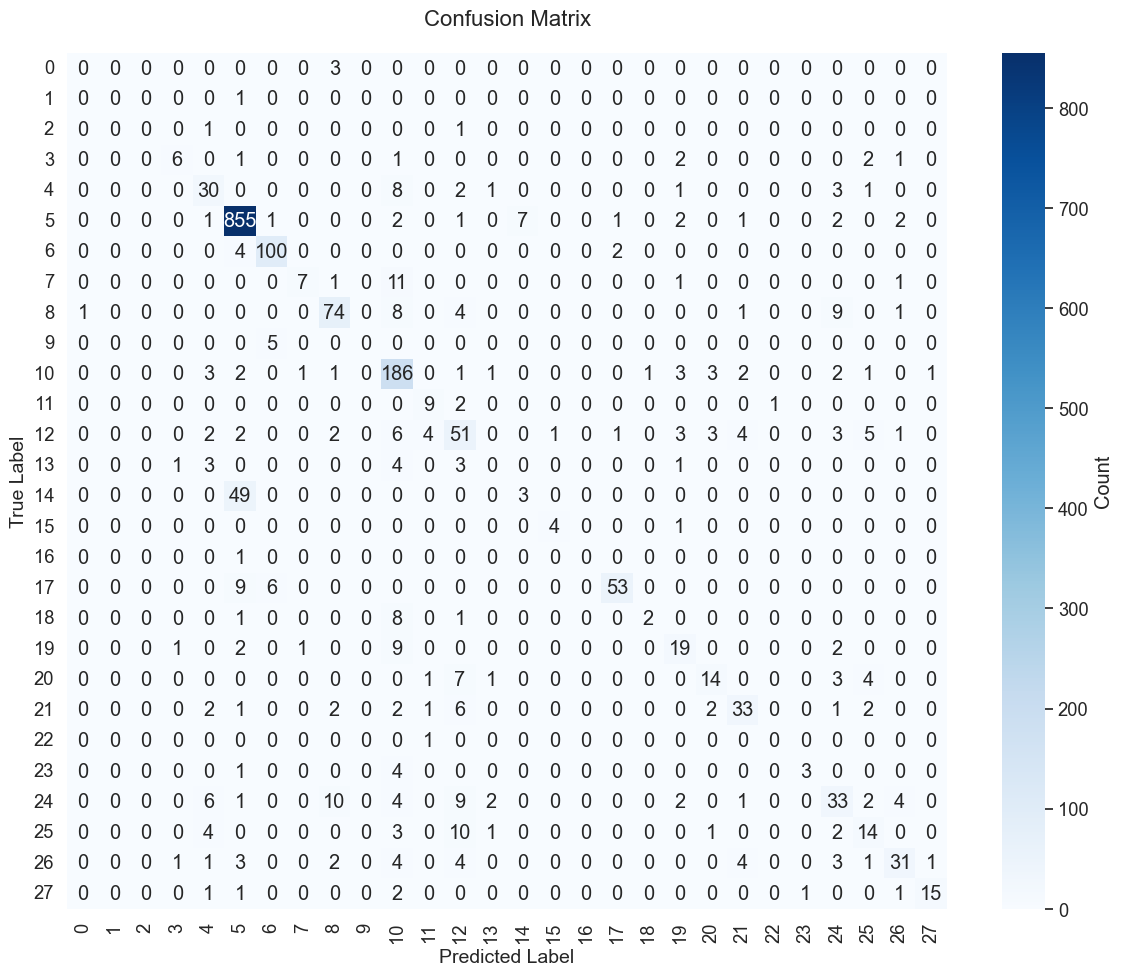

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import log_loss

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=200,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
#    Replace y_true and y_pred with your variables
y_true = y_val
y_pred = y_pred
cm = confusion_matrix(y_true, y_pred)

# 2. (Optional) If you want the labels in sorted order, e.g. [0,1,2,...]
classes = np.unique(y_true)

# 3. Plot
plt.figure(figsize=(12,10))
sns.set(font_scale=1.2)  # for label size
ax = sns.heatmap(
    cm,
    annot=True,            # write the data in each cell
    fmt='d',               # integer format
    cmap='Blues',          # or any other colormap
    cbar_kws={'label': 'Count'},
    xticklabels=classes,
    yticklabels=classes
)

# 4. Decorations
ax.set_title('Confusion Matrix', fontsize=16, pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0)     # keep y‐tick labels horizontal
plt.xticks(rotation=90)    # rotate x‐tick labels if they’re long
plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.105931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 90932, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [17:44:44] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7956656346749226
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.71      0.38      0.50        13
           4       0.58      0.61      0.60        46
           5       0.91      0.98      0.94       875
           6       0.91      0.94      0.93       106
           7       0.70      0.33      0.45        21
           8       0.75      0.82      0.78        98
           9       0.00      0.00      0.00         5
          10       0.70      0.91      0.79       208
          11       0.57      0.67      0.62        12
          12       0.51      0.58      0.54        88
          13       0.00      0.00      0.00        12
          14       0.12      0.02      0.03        52
          15       0.80      0.80      0.80         5


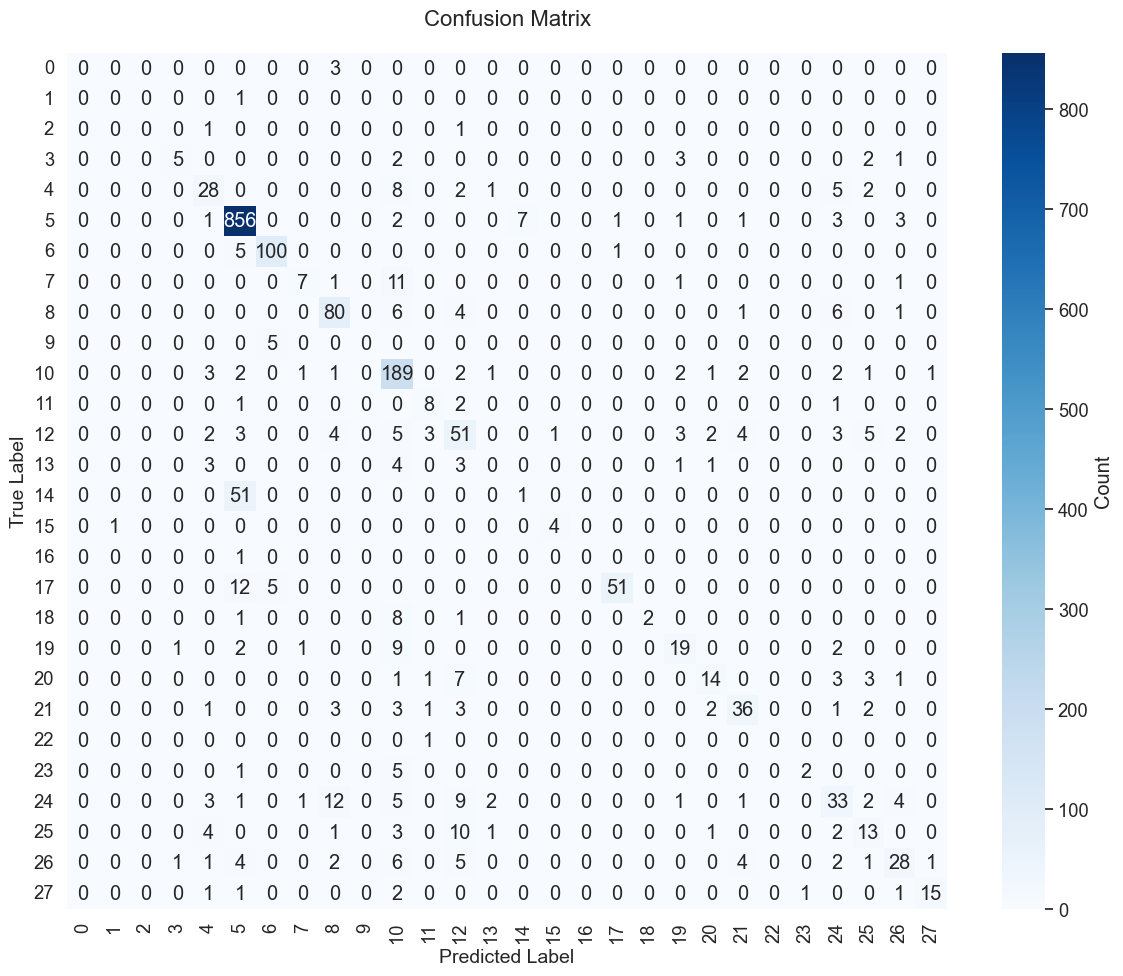

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import log_loss

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
   ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('svm', SVC(C=200,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
     ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    ('bsmote', BorderlineSMOTE(random_state=42, k_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
#    Replace y_true and y_pred with your variables
y_true = y_val
y_pred = y_pred
cm = confusion_matrix(y_true, y_pred)

# 2. (Optional) If you want the labels in sorted order, e.g. [0,1,2,...]
classes = np.unique(y_true)

# 3. Plot
plt.figure(figsize=(12,10))
sns.set(font_scale=1.2)  # for label size
ax = sns.heatmap(
    cm,
    annot=True,            # write the data in each cell
    fmt='d',               # integer format
    cmap='Blues',          # or any other colormap
    cbar_kws={'label': 'Count'},
    xticklabels=classes,
    yticklabels=classes
)

# 4. Decorations
ax.set_title('Confusion Matrix', fontsize=16, pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0)     # keep y‐tick labels horizontal
plt.xticks(rotation=90)    # rotate x‐tick labels if they’re long
plt.tight_layout()
plt.show()


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.113293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 98038, number of used features: 300
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from s

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [18:27:25] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7925696594427245
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.57      0.31      0.40        13
           4       0.56      0.63      0.59        46
           5       0.90      0.98      0.94       875
           6       0.91      0.94      0.93       106
           7       0.78      0.33      0.47        21
           8       0.78      0.76      0.77        98
           9       0.00      0.00      0.00         5
          10       0.70      0.90      0.79       208
          11       0.57      0.67      0.62        12
          12       0.48      0.55      0.51        88
          13       0.00      0.00      0.00        12
          14       0.25      0.02      0.04        52
          15       0.80      0.80      0.80         5


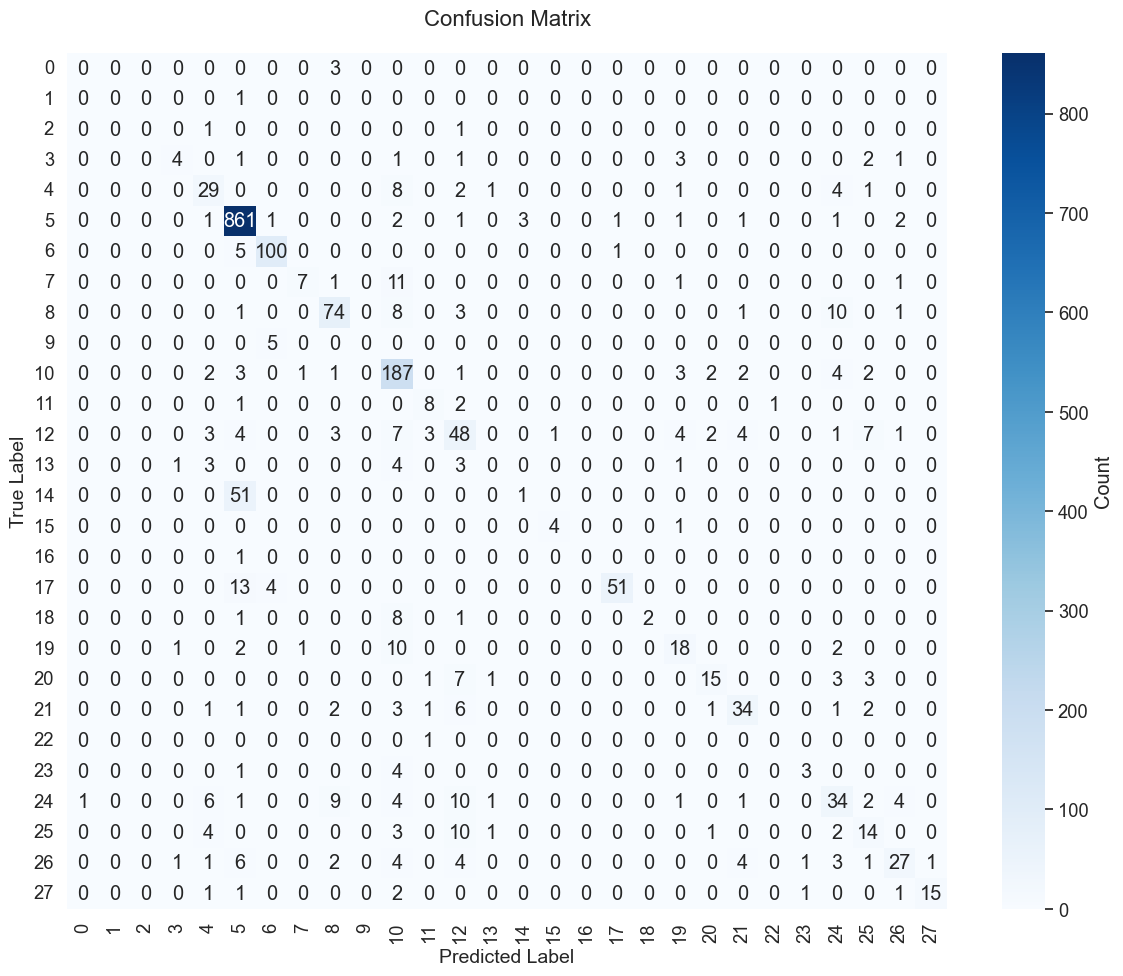

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import log_loss

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
  ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
   ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('svm', SVC(C=200,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
    ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
     ('adasyn', ADASYN(random_state=42, n_neighbors=3)),
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
#    Replace y_true and y_pred with your variables
y_true = y_val
y_pred = y_pred
cm = confusion_matrix(y_true, y_pred)

# 2. (Optional) If you want the labels in sorted order, e.g. [0,1,2,...]
classes = np.unique(y_true)

# 3. Plot
plt.figure(figsize=(12,10))
sns.set(font_scale=1.2)  # for label size
ax = sns.heatmap(
    cm,
    annot=True,            # write the data in each cell
    fmt='d',               # integer format
    cmap='Blues',          # or any other colormap
    cbar_kws={'label': 'Count'},
    xticklabels=classes,
    yticklabels=classes
)

# 4. Decorations
ax.set_title('Confusion Matrix', fontsize=16, pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0)     # keep y‐tick labels horizontal
plt.xticks(rotation=90)    # rotate x‐tick labels if they’re long
plt.tight_layout()
plt.show()


Number of classes: 28
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008357 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 7752, number of used features: 300
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332204
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from score -3.332205
[LightGBM] [Info] Start training from sc

/Users/davinagreen/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [19:53:57] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Validation Accuracy: 0.7966976264189887
Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.60      0.46      0.52        13
           4       0.61      0.61      0.61        46
           5       0.91      0.99      0.95       875
           6       0.91      0.95      0.93       106
           7       0.75      0.43      0.55        21
           8       0.78      0.81      0.79        98
           9       0.00      0.00      0.00         5
          10       0.72      0.87      0.79       208
          11       0.53      0.75      0.62        12
          12       0.51      0.56      0.53        88
          13       0.00      0.00      0.00        12
          14       1.00      0.02      0.04        52
          15       0.83      1.00      0.91         5


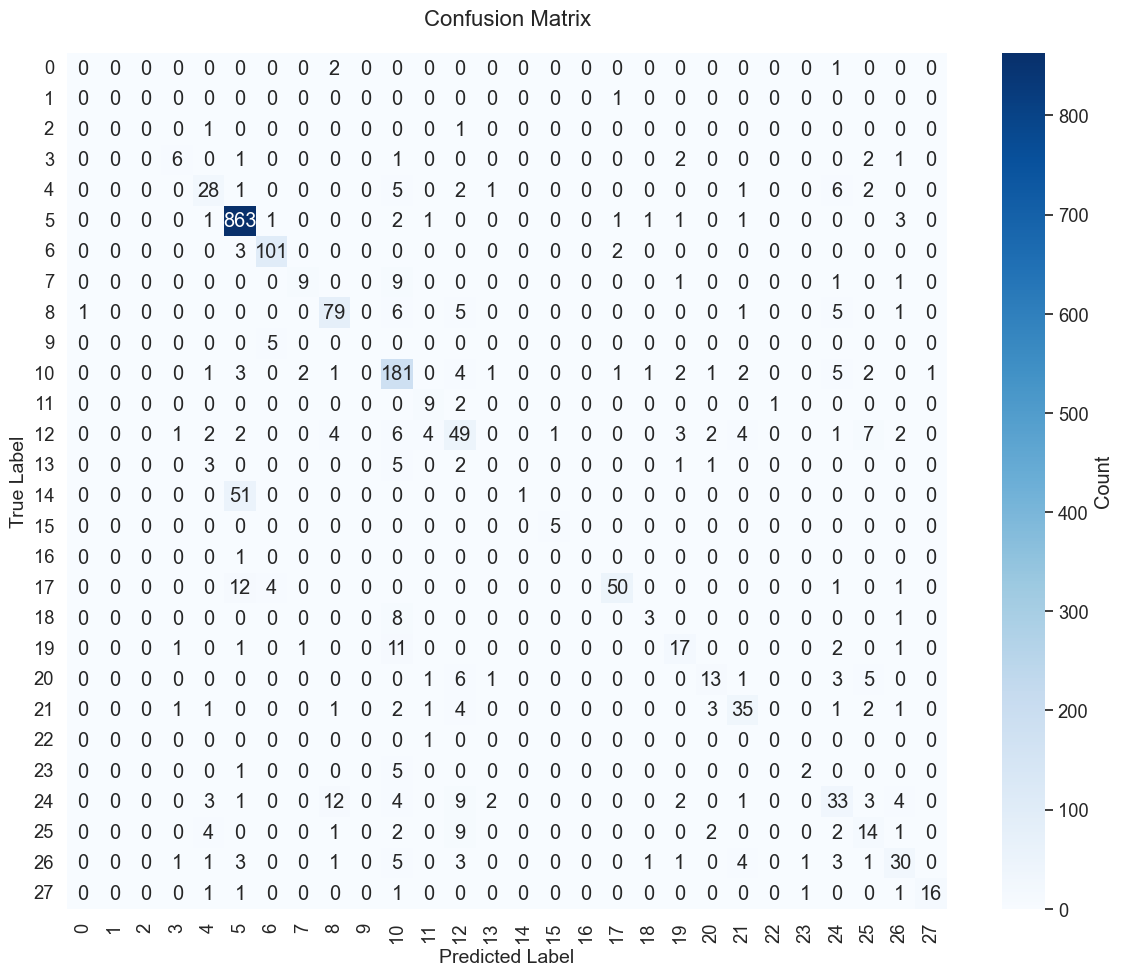

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import log_loss

# 1. Cost-Sensitive Wrapper for XGBoost
class CostSensitiveXGBClassifier(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sample_weight = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=sample_weight, **kwargs)

# 2. Logistic Regression Tuning Function
# def lr_train(X, y, cw=None):
#     kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     C_values = np.logspace(-2, 2, 10)
#     grid = GridSearchCV(
#         LogisticRegression(random_state=42, max_iter=1000, class_weight=cw),
#         {'C': C_values},
#         cv=kf,
#         scoring='accuracy',
#         n_jobs=4,
#         verbose=1
#     )
#     grid.fit(X, y)
#     print(f"\nBest LR CV accuracy: {grid.best_score_:.4f}")
#     print("Best C:", grid.best_params_['C'])
#     return grid.best_estimator_

# 3. Load & Split Data
X = pd.read_csv('X_train_cleaned.csv')
y = pd.read_csv('y_train_cleaned.csv')['label']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# 4. Define Oversampling + Model Pipelines

# 4a. ADASYN + Logistic Regression
pipe_lr = ImbPipeline(steps=[
 
    ('lr', LogisticRegression(C=0.215,solver='lbfgs', class_weight='balanced', max_iter=2000, random_state=42))
])

# 4b. BorderlineSMOTE + SVM
pipe_svm = ImbPipeline(steps=[
 
    ('svm', SVC(C=200,class_weight='balanced', probability=True, random_state=42))
])

# 4c. ADASYN + LightGBM
pipe_lgbm = ImbPipeline(steps=[
   
    ('lgbm', LGBMClassifier(learning_rate=0.05,n_estimators=300,class_weight='balanced',random_state=42))
])

# 4d. BorderlineSMOTE + Cost-Sensitive XGBoost
pipe_xgb = ImbPipeline(steps=[
    
    ('xgb', CostSensitiveXGBClassifier(
        learning_rate=0.1,
        n_estimators=200,
        objective='multi:softprob',
        num_class=num_classes,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ))
])

# # 5. Tune Logistic Regression (not in pipeline)
# best_lr = lr_train(X_train, y_train, cw='balanced')

# 6. Ensemble Voting (replace RF with SVM)
ensemble = VotingClassifier(
    estimators=[
        ('lr_best',pipe_lr),
        ('svm', pipe_svm),
        ('lgbm', pipe_lgbm),
        ('xgb', pipe_xgb)
    ],
    voting='soft'
)

# 7. Train Ensemble
ensemble.fit(X_train, y_train)

# 8. Evaluate on Validation Set
y_pred = ensemble.predict(X_val)
print("Ensemble Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Ensemble Classification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

import numpy as np

def weighted_log_loss_formula(y_true, y_pred_proba, eps=1e-15):
    """
    按照公式 L = - ∑_i w_{y_i} * log(p̂_i)，w_y = 1 / f_y，
    最后除以 N 得到 average per sample。
    y_true: array-like (N,)  真实标签 0…C-1
    y_pred_proba: array (N, C)  模型预测的各类概率
    """
    y_true = np.asarray(y_true)
    N, C = y_pred_proba.shape

    # 1) 计算每个类别的频次 f_y
    class_counts = np.bincount(y_true, minlength=C)
    # 如果某类在这一集合里完全没出现，就把它当 1 处理，避免除零
    class_counts[class_counts == 0] = 1

    # 2) w_y = 1 / f_y
    class_weights = 1.0 / class_counts

    # 3) 提取每个样本的 p̂_i = P(y_true[i])
    p = y_pred_proba[np.arange(N), y_true]
    p = np.clip(p, eps, 1 - eps)  # 避免 log(0)

    # 4) 计算加权 log‐loss
    losses = - class_weights[y_true] * np.log(p)

    # 5) 返回平均 per sample
    return losses.sum() / N

# —— 一次性算 train & val loss —— 
y_train_proba = ensemble.predict_proba(X_train)
y_val_proba   = ensemble.predict_proba(X_val)

train_wll = weighted_log_loss_formula(y_train, y_train_proba)
val_wll   = weighted_log_loss_formula(y_val,   y_val_proba)

print(f"Training weighted log‐loss:   {train_wll:.4f}")
print(f"Validation weighted log‐loss: {val_wll:.4f}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
#    Replace y_true and y_pred with your variables
y_true = y_val
y_pred = y_pred
cm = confusion_matrix(y_true, y_pred)

# 2. (Optional) If you want the labels in sorted order, e.g. [0,1,2,...]
classes = np.unique(y_true)

# 3. Plot
plt.figure(figsize=(12,10))
sns.set(font_scale=1.2)  # for label size
ax = sns.heatmap(
    cm,
    annot=True,            # write the data in each cell
    fmt='d',               # integer format
    cmap='Blues',          # or any other colormap
    cbar_kws={'label': 'Count'},
    xticklabels=classes,
    yticklabels=classes
)

# 4. Decorations
ax.set_title('Confusion Matrix', fontsize=16, pad=20)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
plt.yticks(rotation=0)     # keep y‐tick labels horizontal
plt.xticks(rotation=90)    # rotate x‐tick labels if they’re long
plt.tight_layout()
plt.show()


TypeError: ADASYN.__init__() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given